<a href="https://colab.research.google.com/github/vaino118/Security-Analytics_S2_2026---Practical-Labs-Lab-1-Lab-2-Lab-3-/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

print("Please select egs_text_training.csv and egs_text_investigation.csv")
uploaded = files.upload()   # a file dialog will open

train = pd.read_csv("egs_text_training.csv")
inv   = pd.read_csv("egs_text_investigation.csv")

print("Training shape:", train.shape)
print("Investigation shape:", inv.shape)

Please select egs_text_training.csv and egs_text_investigation.csv


Saving egs_text_investigation.csv to egs_text_investigation (1).csv
Saving egs_text_training.csv to egs_text_training (1).csv
Training shape: (2000, 6)
Investigation shape: (171, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

# Fixed seed for reproducibility
SEED = 8213026
np.random.seed(SEED)

# Load the two files
train = pd.read_csv("egs_text_training.csv")
inv   = pd.read_csv("egs_text_investigation.csv")

# Convert dates
train["published_at"] = pd.to_datetime(train["published_at"])
inv["published_at"]   = pd.to_datetime(inv["published_at"])

print("Training shape:", train.shape)
print("Investigation shape:", inv.shape)
print()

# Missing values
print("Missing values – Training:")
print(train.isnull().sum())
print()
print("Missing values – Investigation:")
print(inv.isnull().sum())
print()

# Duplicates
print("Full-row duplicates – Training:", train.duplicated().sum())
print("Full-row duplicates – Investigation:", inv.duplicated().sum())
print("Duplicate report_id – Training:", train["report_id"].duplicated().sum())
print("Duplicate report_id – Investigation:", inv["report_id"].duplicated().sum())

Training shape: (2000, 6)
Investigation shape: (171, 5)

Missing values – Training:
report_id         0
published_at      0
source            0
title             0
report_text       0
relevant_label    0
dtype: int64

Missing values – Investigation:
report_id       0
published_at    0
source          0
title           0
report_text     0
dtype: int64

Full-row duplicates – Training: 0
Full-row duplicates – Investigation: 0
Duplicate report_id – Training: 0
Duplicate report_id – Investigation: 0


Source counts – Training:
source
Vendor Advisory            439
Commercial Intelligence    422
CERT-NA                    391
Regional ISAC              381
Open-source Research       367
Name: count, dtype: int64

Source counts – Investigation:
source
Regional ISAC              40
Vendor Advisory            36
Open-source Research       34
Commercial Intelligence    30
CERT-NA                    29
Regional Energy ISAC        1
OT Security Vendor          1
Name: count, dtype: int64



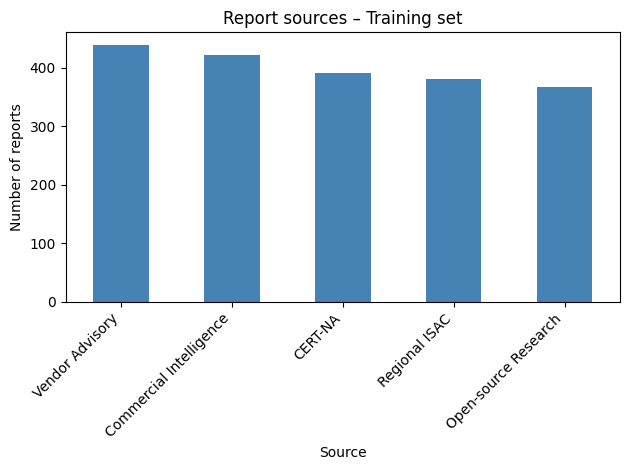

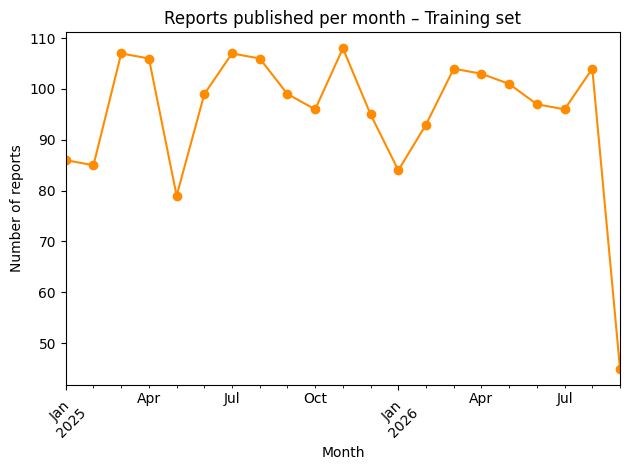

In [ ]:
print("Source counts – Training:")
print(train["source"].value_counts())
print()
print("Source counts – Investigation:")
print(inv["source"].value_counts())
print()

# Simple bar chart of sources in training
train["source"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Report sources – Training set")
plt.xlabel("Source")
plt.ylabel("Number of reports")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Reports per month (training)
train["year_month"] = train["published_at"].dt.to_period("M")
monthly = train.groupby("year_month").size()
monthly.plot(kind="line", marker="o", color="darkorange")
plt.title("Reports published per month – Training set")
plt.xlabel("Month")
plt.ylabel("Number of reports")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def clean_text(text):
    """Simple, reproducible cleaning steps."""
    if pd.isna(text):
        return ""
    text = str(text).lower()                       # lower-case
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)       # keep only letters, numbers, spaces
    text = re.sub(r"\s+", " ", text).strip()        # collapse extra spaces
    return text

# Combine title and body into one field
train["full_text"] = (train["title"].fillna("") + " " + train["report_text"].fillna("")).apply(clean_text)
inv["full_text"]   = (inv["title"].fillna("")   + " " + inv["report_text"].fillna("")).apply(clean_text)

print("Example cleaned text (first training report):")
print(train["full_text"].iloc[0][:300])

Example cleaned text (first training report):
general technology bulletin researchers published a general vulnerability affecting energy utilities the advisory applies to versions not deployed by the organisation and contains no evidence of active exploitation in southern africa


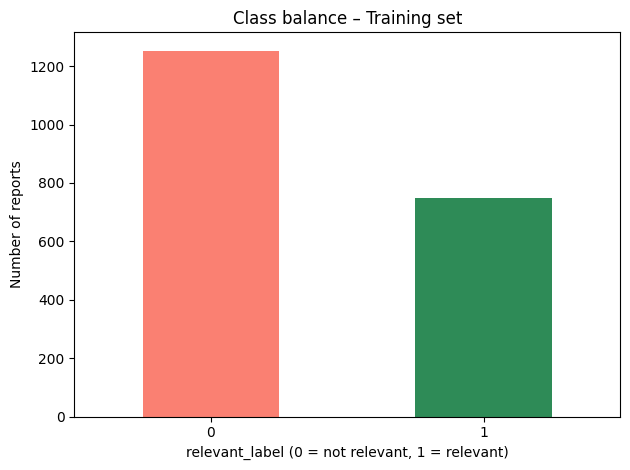

Top 15 terms in relevant reports:
              term  count
0           vendor    734
1             node    680
2             sync    680
3          example    680
4       industrial    562
5         observed    401
6         campaign    390
7         activity    378
8           access    375
9      operational    368
10  infrastructure    348
11           actor    347
12          energy    325
13       operators    318
14        scanning    313


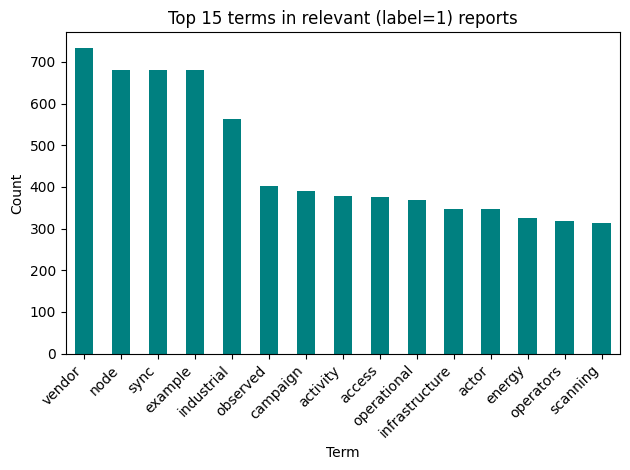

In [ ]:
# 1. Class balance bar chart
train["relevant_label"].value_counts().sort_index().plot(
    kind="bar", color=["salmon", "seagreen"]
)
plt.title("Class balance – Training set")
plt.xlabel("relevant_label (0 = not relevant, 1 = relevant)")
plt.ylabel("Number of reports")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Most frequent words in relevant reports (label = 1)
relevant_text = " ".join(train.loc[train["relevant_label"] == 1, "full_text"])
words = relevant_text.split()
# remove very short tokens
words = [w for w in words if len(w) > 3]
top_words = Counter(words).most_common(15)

words_df = pd.DataFrame(top_words, columns=["term", "count"])
print("Top 15 terms in relevant reports:")
print(words_df)

words_df.plot(x="term", y="count", kind="bar", legend=False, color="teal")
plt.title("Top 15 terms in relevant (label=1) reports")
plt.xlabel("Term")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import re
import pandas as pd
import numpy as np

SEED = 8213026
np.random.seed(SEED)

# ----- Load the files again -----
train = pd.read_csv("egs_text_training.csv")
inv   = pd.read_csv("egs_text_investigation.csv")

print("Training shape:", train.shape)
print("Investigation shape:", inv.shape)

# ----- Extraction patterns -----
IP_PATTERN     = r"\b(?:\d{1,3}\.){3}\d{1,3}\b"
DOMAIN_PATTERN = r"\b(?:[a-z0-9](?:[a-z0-9\-]{0,61}[a-z0-9])?\.)+(?:example|com|net|org|io)\b"
HASH_PATTERN   = r"\b[a-fA-F0-9]{32,64}\b"
ACTOR_PATTERN  = r"\b(?:Kalahari Jackal|Sandstorm Loader|Copper Dune|Red Kudu|Night Heron|BreakerFox|DustRAT|GridLock)\b"

def extract_entities(report_id, text):
    if pd.isna(text):
        return []
    text = str(text)
    rows = []
    for m in re.finditer(IP_PATTERN, text):
        rows.append({"report_id": report_id, "entity_type": "ipv4", "entity_value": m.group()})
    for m in re.finditer(DOMAIN_PATTERN, text, flags=re.IGNORECASE):
        rows.append({"report_id": report_id, "entity_type": "domain", "entity_value": m.group().lower()})
    for m in re.finditer(HASH_PATTERN, text):
        rows.append({"report_id": report_id, "entity_type": "sha256", "entity_value": m.group().lower()})
    for m in re.finditer(ACTOR_PATTERN, text, flags=re.IGNORECASE):
        rows.append({"report_id": report_id, "entity_type": "threat_actor_or_malware", "entity_value": m.group()})
    return rows

# ----- Run extraction -----
inv["full_raw"] = inv["title"].fillna("") + " " + inv["report_text"].fillna("")
all_entities = []
for _, row in inv.iterrows():
    all_entities.extend(extract_entities(row["report_id"], row["full_raw"]))

extracted = pd.DataFrame(all_entities).drop_duplicates()
print("Total unique entities extracted:", len(extracted))
print(extracted["entity_type"].value_counts())
print()
print(extracted.head(15))

Training shape: (2000, 6)
Investigation shape: (171, 5)
Total unique entities extracted: 158
entity_type
threat_actor_or_malware    60
domain                     49
ipv4                       48
sha256                      1
Name: count, dtype: int64

   report_id              entity_type            entity_value
0   TRN03002                     ipv4          198.51.100.143
1   TRN03002                   domain  node-3002-sync.example
2   TRN03002  threat_actor_or_malware         Kalahari Jackal
3   TRN03003                     ipv4          198.51.100.144
4   TRN03003                   domain  node-3003-sync.example
5   TRN03003  threat_actor_or_malware         Kalahari Jackal
6   TRN03003  threat_actor_or_malware                 DustRAT
7   TRN03004                     ipv4          198.51.100.145
8   TRN03004                   domain  node-3004-sync.example
9   TRN03004  threat_actor_or_malware              BreakerFox
10  TRN03005                     ipv4          198.51.100.146
11  

In [ ]:
# High-value indicators linked to the current campaign
HIGH_VALUE = {
    "203.0.113.77",
    "198.51.100.44",
    "desert-sync.example",
    "maintenance-check.example",
    "8e50b5f71c8efa22abe51646264f41367451d4acc42134c8c2b787c3190bc393",
    "kalahari jackal",
    "sandstorm loader"
}

def score_relevance(entity_value, entity_type):
    val = str(entity_value).lower()
    if val in HIGH_VALUE or any(h in val for h in HIGH_VALUE):
        return "High – linked to current Kalahari Jackal / Sandstorm campaign"
    if entity_type == "threat_actor_or_malware":
        return "Medium – known actor or malware name"
    if entity_type in ("ipv4", "domain", "sha256"):
        return "Low – generic indicator, needs internal validation"
    return "Unknown"

extracted["analytical_relevance"] = extracted.apply(
    lambda r: score_relevance(r["entity_value"], r["entity_type"]), axis=1
)

# Keep the four required columns and export
out = extracted[["report_id", "entity_type", "entity_value", "analytical_relevance"]]
out.to_csv("extracted_iocs.csv", index=False)

print("Saved extracted_iocs.csv")
print()
print("High-relevance entities:")
print(out[out["analytical_relevance"].str.startswith("High")].to_string())

Saved extracted_iocs.csv

High-relevance entities:
    report_id              entity_type                                                      entity_value                                           analytical_relevance
2    TRN03002  threat_actor_or_malware                                                   Kalahari Jackal  High – linked to current Kalahari Jackal / Sandstorm campaign
5    TRN03003  threat_actor_or_malware                                                   Kalahari Jackal  High – linked to current Kalahari Jackal / Sandstorm campaign
15   TRN03007  threat_actor_or_malware                                                   Kalahari Jackal  High – linked to current Kalahari Jackal / Sandstorm campaign
30   TRN03017  threat_actor_or_malware                                                   Kalahari Jackal  High – linked to current Kalahari Jackal / Sandstorm campaign
33   TRN03036  threat_actor_or_malware                                                   Kalahari Jackal  Hig

In [ ]:
ioc_feed = pd.read_csv("egs_ioc_feed.csv")

extracted["entity_value_norm"] = extracted["entity_value"].str.lower()
ioc_feed["indicator_value_norm"] = ioc_feed["indicator_value"].str.lower()

matched = extracted.merge(
    ioc_feed,
    left_on="entity_value_norm",
    right_on="indicator_value_norm",
    how="inner"
)

print("Number of matches:", len(matched))
print()
print(matched[["report_id", "entity_type", "entity_value", "ioc_id",
               "confidence", "context", "first_seen", "recommended_action"]].to_string())

Number of matches: 6

  report_id entity_type                                                      entity_value   ioc_id confidence                                                context  first_seen                        recommended_action
0   RPT9001        ipv4                                                      203.0.113.77  IOC9001       High                  Kalahari Jackal access infrastructure  2026-10-16    Block and review vendor authentication
1   RPT9001      domain                                         maintenance-check.example  IOC9005     Medium  Credential-harvesting domain targeting energy vendors  2026-10-14           Review vendor mail and web logs
2   RPT9002        ipv4                                                     198.51.100.44  IOC9003       High                   Sandstorm Loader command-and-control  2026-10-16                  Block at egress and hunt
3   RPT9002      domain                                               desert-sync.example  IOC9002    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import numpy as np
import pandas as pd
import re

SEED = 8213026
np.random.seed(SEED)

# ----- Clean text (same function as B1) -----
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Reload if needed
train = pd.read_csv("egs_text_training.csv")
inv   = pd.read_csv("egs_text_investigation.csv")

train["full_text"] = (train["title"].fillna("") + " " + train["report_text"].fillna("")).apply(clean_text)
inv["full_text"]   = (inv["title"].fillna("")   + " " + inv["report_text"].fillna("")).apply(clean_text)

X = train["full_text"]
y = train["relevant_label"]

# Stratified split + fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

# TF-IDF with unigrams + bigrams, English stop-words
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Simple, transparent classifier
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
clf.fit(X_train_tfidf, y_train)

# Predictions on the held-out test set
y_pred = clf.predict(X_test_tfidf)

# Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fnr  = cm[1, 0] / (cm[1, 0] + cm[1, 1])   # false-negative rate

print("Confusion matrix:")
print(cm)
print()
print(f"Accuracy:           {acc:.3f}")
print(f"Precision:          {prec:.3f}")
print(f"Recall:             {rec:.3f}")
print(f"F1-score:           {f1:.3f}")
print(f"False-negative rate:{fnr:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not relevant (0)", "Relevant (1)"]))

Confusion matrix:
[[311   2]
 [  8 179]]

Accuracy:           0.980
Precision:          0.989
Recall:             0.957
F1-score:           0.973
False-negative rate:0.043

                  precision    recall  f1-score   support

Not relevant (0)       0.97      0.99      0.98       313
    Relevant (1)       0.99      0.96      0.97       187

        accuracy                           0.98       500
       macro avg       0.98      0.98      0.98       500
    weighted avg       0.98      0.98      0.98       500



In [ ]:
# Score every investigation report
inv_tfidf = vectorizer.transform(inv["full_text"])
inv["relevance_prob"] = clf.predict_proba(inv_tfidf)[:, 1]
inv["predicted_label"] = clf.predict(inv_tfidf)

# Top 15 by probability
top15 = inv.sort_values("relevance_prob", ascending=False).head(15)
top15_out = top15[["report_id", "published_at", "source", "title", "relevance_prob", "predicted_label"]]
top15_out.to_csv("top_15_relevant_reports.csv", index=False)

print("Saved top_15_relevant_reports.csv")
print()
print(top15_out.to_string())

Saved top_15_relevant_reports.csv

    report_id published_at                   source                                        title  relevance_prob  predicted_label
132  TRN03133   2026-08-03     Open-source Research  Industrial protocol reconnaissance observed        0.976850                1
7    TRN03008   2026-01-04     Open-source Research         Vendor access abused in OT intrusion        0.976216                1
83   TRN03084   2025-06-22     Open-source Research        Campaign targets industrial operators        0.970612                1
95   TRN03096   2025-06-30     Open-source Research         Vendor access abused in OT intrusion        0.969910                1
162  TRN03163   2026-02-22          Vendor Advisory         Vendor access abused in OT intrusion        0.969046                1
88   TRN03089   2025-12-15            Regional ISAC        Campaign targets industrial operators        0.966650                1
108  TRN03109   2026-05-08          Vendor Advisory    

In [ ]:
adv = pd.read_csv("egs_adversarial_text_cases.csv")

def score_text(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return clf.predict_proba(vec)[0, 1]

results = []
for _, row in adv.iterrows():
    p_orig = score_text(row["original_text"])
    p_mod  = score_text(row["modified_text"])
    results.append({
        "case_id": row["case_id"],
        "evasion_technique": row["evasion_technique"],
        "prob_original": round(p_orig, 3),
        "prob_modified": round(p_mod, 3),
        "drop": round(p_orig - p_mod, 3)
    })

adv_results = pd.DataFrame(results)
print(adv_results.to_string())
print()
print("Average probability drop:", round(adv_results["drop"].mean(), 3))

  case_id                              evasion_technique  prob_original  prob_modified   drop
0   ATX01  character substitution and defanged indicator          0.840          0.764  0.076
1   ATX02                          semantic substitution          0.863          0.663  0.201
2   ATX03                                keyword removal          0.776          0.631  0.144
3   ATX04                            euphemistic wording          0.799          0.659  0.140
4   ATX05                   protocol/function paraphrase          0.667          0.754 -0.087

Average probability drop: 0.095


In [ ]:
#C1. Simulation model design

import pandas as pd
import networkx as nx
import numpy as np

SEED = 8213026
np.random.seed(SEED)

edges   = pd.read_csv("egs_network_topology_edges.csv")
posture = pd.read_csv("egs_host_security_posture.csv")
assets  = pd.read_csv("egs_asset_inventory.csv")

# Directed graph
G = nx.from_pandas_edgelist(
    edges,
    source="source_asset",
    target="target_asset",
    edge_attr=True,
    create_using=nx.DiGraph()
)

# Add host susceptibility as a node attribute
sus_dict = dict(zip(posture["asset_id"], posture["susceptibility"]))
nx.set_node_attributes(G, sus_dict, "susceptibility")

# Add zone and criticality
zone_dict = dict(zip(assets["asset_id"], assets["zone"]))
crit_dict = dict(zip(assets["asset_id"], assets["criticality"]))
nx.set_node_attributes(G, zone_dict, "zone")
nx.set_node_attributes(G, crit_dict, "criticality")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print()
print("Starting node VENDOR-LT-07 exists:", "VENDOR-LT-07" in G.nodes)
print("Susceptibility of VENDOR-LT-07:", G.nodes["VENDOR-LT-07"].get("susceptibility"))
print()
print("Sample edges from VENDOR-LT-07:")
print(list(G.out_edges("VENDOR-LT-07", data=True))[:3])

In [ ]:
#C2. Monte Carlo control experiments
#Simulation function and run all scenarios

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

SEED = 8213026
np.random.seed(SEED)
N_RUNS = 1000
MAX_STEPS = 20

# ----- Load data -----
edges   = pd.read_csv("egs_network_topology_edges.csv")
posture = pd.read_csv("egs_host_security_posture.csv")
assets  = pd.read_csv("egs_asset_inventory.csv")
scenarios = pd.read_csv("egs_simulation_scenarios.csv")

# Build base graph
G_base = nx.from_pandas_edgelist(
    edges, source="source_asset", target="target_asset",
    edge_attr=True, create_using=nx.DiGraph()
)
sus_dict = dict(zip(posture["asset_id"], posture["susceptibility"]))
zone_dict = dict(zip(assets["asset_id"], assets["zone"]))
crit_dict = dict(zip(assets["asset_id"], assets["criticality"]))
nx.set_node_attributes(G_base, sus_dict, "susceptibility")
nx.set_node_attributes(G_base, zone_dict, "zone")
nx.set_node_attributes(G_base, crit_dict, "criticality")

# Asset sets we care about
OT_NODES = {n for n, d in G_base.nodes(data=True) if d.get("zone") in ("OT", "OT-DMZ")}
SAFETY_NODES = {n for n, d in G_base.nodes(data=True) if d.get("zone") == "Safety"}
CRITICAL_NODES = {n for n, d in G_base.nodes(data=True) if d.get("criticality") == "Critical"}

# Vendor-path nodes that benefit from patching
VENDOR_PATH = {"VENDOR-LT-07", "VPN-GW-01", "VENDOR-DMZ-01"}

def run_one_simulation(G, scenario, rng):
    """One Monte-Carlo run. Returns dict of outcomes."""
    infected = set(["VENDOR-LT-07"])
    newly_infected = set(["VENDOR-LT-07"])
    time_to_ot = None
    isolation_step = scenario["isolation_delay_steps"]
    patch_f = scenario["patch_factor"]
    seg_f = scenario["segmentation_factor"]
    post_det_f = scenario["post_detection_transmission_factor"]

    for step in range(1, MAX_STEPS + 1):
        if not newly_infected:
            break
        candidates = set()
        for src in list(newly_infected):
            # After isolation delay, Windows assets stop spreading (rapid isolation)
            if step > isolation_step and G.nodes[src].get("zone") in ("Vendor", "DMZ", "IT", "OT-DMZ", "OT"):
                # still allow already-infected nodes to be counted, but reduce further spread
                pass
            for _, tgt, edata in G.out_edges(src, data=True):
                if tgt in infected:
                    continue
                base_p = edata["base_transmission_probability"]
                # Apply segmentation factor on DMZ->OT and OT lateral edges
                if edata.get("target_zone") in ("OT", "OT-DMZ", "Safety") or edata.get("source_zone") in ("OT", "OT-DMZ"):
                    base_p *= seg_f
                # Apply patch factor on vendor-path sources
                if src in VENDOR_PATH:
                    base_p *= patch_f
                # After isolation delay, further reduce transmission
                if step > isolation_step:
                    base_p *= post_det_f
                # Host susceptibility
                sus = G.nodes[tgt].get("susceptibility", 0.5)
                p = min(1.0, base_p * sus)
                if rng.random() < p:
                    candidates.add(tgt)
        newly_infected = candidates
        infected.update(candidates)
        if time_to_ot is None and infected & OT_NODES:
            time_to_ot = step

    reached_ot = int(bool(infected & OT_NODES))
    reached_safety = int(bool(infected & SAFETY_NODES))
    n_critical = len(infected & CRITICAL_NODES)
    n_total = len(infected)
    return {
        "reached_ot": reached_ot,
        "reached_safety": reached_safety,
        "n_critical": n_critical,
        "n_total": n_total,
        "time_to_ot": time_to_ot if time_to_ot is not None else MAX_STEPS + 1
    }

# ----- Run 1000 iterations for every scenario -----
summary_rows = []
all_results = {}

for _, sc in scenarios.iterrows():
    rng = np.random.default_rng(SEED)   # same seed for every scenario so comparison is fair
    results = [run_one_simulation(G_base, sc, rng) for _ in range(N_RUNS)]
    df = pd.DataFrame(results)
    all_results[sc["scenario_id"]] = df

    row = {
        "scenario_id": sc["scenario_id"],
        "scenario_name": sc["scenario_name"],
        "prob_reach_ot": df["reached_ot"].mean(),
        "prob_reach_safety": df["reached_safety"].mean(),
        "mean_critical_infected": df["n_critical"].mean(),
        "mean_total_infected": df["n_total"].mean(),
        "median_time_to_ot": df["time_to_ot"].median(),
        "p90_total_infected": df["n_total"].quantile(0.90)
    }
    summary_rows.append(row)
    print(f"Finished {sc['scenario_id']}: OT prob = {row['prob_reach_ot']:.3f}")

summary = pd.DataFrame(summary_rows)
summary.to_csv("simulation_summary.csv", index=False)
print()
print("Saved simulation_summary.csv")
print(summary.to_string())

Finished S0: OT prob = 0.054
Finished S1: OT prob = 0.006
Finished S2: OT prob = 0.010
Finished S3: OT prob = 0.011
Finished S4: OT prob = 0.000

Saved simulation_summary.csv
  scenario_id               scenario_name  prob_reach_ot  prob_reach_safety  mean_critical_infected  mean_total_infected  median_time_to_ot  p90_total_infected
0          S0            Current controls          0.054              0.001                   0.959                2.001               21.0                 4.0
1          S1           Patch vendor path          0.006              0.000                   0.272                1.276               21.0                 2.0
2          S2  Strengthen OT segmentation          0.010              0.000                   0.885                1.906               21.0                 3.0
3          S3         Rapid EDR isolation          0.011              0.000                   0.889                1.894               21.0                 3.0
4          S4           C

Risk reduction versus current controls (S0):
  scenario_id               scenario_name  prob_reach_ot  abs_reduction_ot  rel_reduction_ot  prob_reach_safety  mean_critical_infected
0          S0            Current controls          0.054             0.000          0.000000              0.001                   0.959
1          S1           Patch vendor path          0.006             0.048          0.888889              0.000                   0.272
2          S2  Strengthen OT segmentation          0.010             0.044          0.814815              0.000                   0.885
3          S3         Rapid EDR isolation          0.011             0.043          0.796296              0.000                   0.889
4          S4           Combined controls          0.000             0.054          1.000000              0.000                   0.261


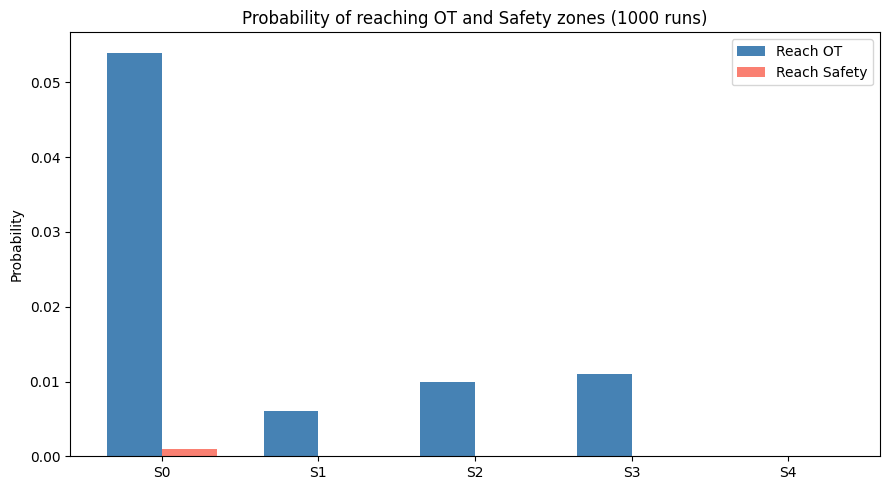

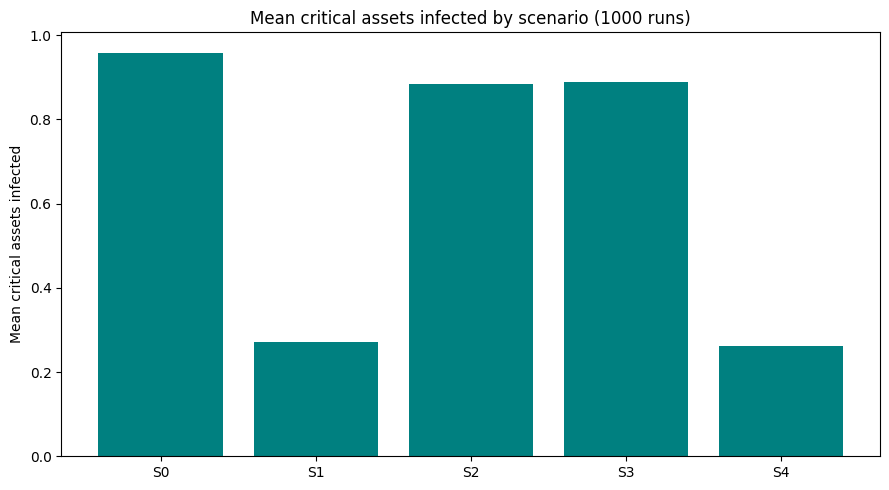

In [ ]:
# Absolute and relative risk reduction vs S0 (current controls)
baseline = summary.loc[summary["scenario_id"] == "S0"].iloc[0]

summary["abs_reduction_ot"] = baseline["prob_reach_ot"] - summary["prob_reach_ot"]
summary["rel_reduction_ot"] = summary["abs_reduction_ot"] / baseline["prob_reach_ot"]
summary["abs_reduction_safety"] = baseline["prob_reach_safety"] - summary["prob_reach_safety"]
summary["rel_reduction_safety"] = np.where(
    baseline["prob_reach_safety"] > 0,
    summary["abs_reduction_safety"] / baseline["prob_reach_safety"],
    0
)

print("Risk reduction versus current controls (S0):")
print(summary[["scenario_id", "scenario_name", "prob_reach_ot", "abs_reduction_ot", "rel_reduction_ot",
               "prob_reach_safety", "mean_critical_infected"]].to_string())

# Plot 1 – Probability of reaching OT and Safety
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary["prob_reach_ot"], w, label="Reach OT", color="steelblue")
ax.bar(x + w/2, summary["prob_reach_safety"], w, label="Reach Safety", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(summary["scenario_id"])
ax.set_ylabel("Probability")
ax.set_title("Probability of reaching OT and Safety zones (1000 runs)")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2 – Mean critical assets infected
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(summary["scenario_id"], summary["mean_critical_infected"], color="teal")
ax.set_ylabel("Mean critical assets infected")
ax.set_title("Mean critical assets infected by scenario (1000 runs)")
plt.tight_layout()
plt.show()

In [ ]:
#D1: Train the predictive model

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

SEED = 8213026
np.random.seed(SEED)

# Load data
risk_train = pd.read_csv("egs_daily_risk_training.csv", parse_dates=["date"])
risk_inv   = pd.read_csv("egs_daily_risk_investigation.csv", parse_dates=["date"])

# Features (all daily indicators)
feature_cols = [
    "failed_remote_logins", "new_external_ips", "suspicious_dns_queries",
    "critical_vulnerabilities", "mean_patch_age_days", "high_severity_edr_alerts",
    "ot_scan_attempts", "high_relevance_threat_reports",
    "vendor_access_sessions", "after_hours_admin_actions"
]

X = risk_train[feature_cols]
y = risk_train["incident_within_7d"]

print("Training rows:", len(X))
print("Class balance:")
print(y.value_counts())

# Stratified split + fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

# Random Forest – good for mixed numeric indicators and non-linear patterns
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# Default threshold 0.5 predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fnr  = cm[1, 0] / (cm[1, 0] + cm[1, 1])

print("Confusion matrix:")
print(cm)
print()
print(f"Accuracy:            {acc:.3f}")
print(f"Precision:           {prec:.3f}")
print(f"Recall:              {rec:.3f}")
print(f"F1-score:            {f1:.3f}")
print(f"False-negative rate: {fnr:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No incident (0)", "Incident (1)"]))

Training rows: 540
Class balance:
incident_within_7d
0    402
1    138
Name: count, dtype: int64
Confusion matrix:
[[83 17]
 [ 7 28]]

Accuracy:            0.822
Precision:           0.622
Recall:              0.800
F1-score:            0.700
False-negative rate: 0.200

                 precision    recall  f1-score   support

No incident (0)       0.92      0.83      0.87       100
   Incident (1)       0.62      0.80      0.70        35

       accuracy                           0.82       135
      macro avg       0.77      0.81      0.79       135
   weighted avg       0.84      0.82      0.83       135



In [ ]:
imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importance:")
print(imp.round(3))

Feature importance:
ot_scan_attempts                 0.197
failed_remote_logins             0.167
high_severity_edr_alerts         0.147
new_external_ips                 0.112
suspicious_dns_queries           0.110
mean_patch_age_days              0.079
after_hours_admin_actions        0.062
vendor_access_sessions           0.052
high_relevance_threat_reports    0.042
critical_vulnerabilities         0.032
dtype: float64


In [ ]:
#D2: Score investigation days and export top 10


# Score every investigation day with the trained model
risk_inv["risk_prob"] = clf.predict_proba(risk_inv[feature_cols])[:, 1]
risk_inv["predicted_incident"] = (risk_inv["risk_prob"] >= 0.5).astype(int)

# Top 10 highest-risk days
top10 = risk_inv.sort_values("risk_prob", ascending=False).head(10)
top10_out = top10[["date", "risk_prob", "predicted_incident"] + feature_cols]
top10_out.to_csv("top_10_risk_days.csv", index=False)

print("Saved top_10_risk_days.csv")
print(top10_out[["date", "risk_prob", "predicted_incident"]].to_string())

Saved top_10_risk_days.csv
         date  risk_prob  predicted_incident
27 2026-10-19   0.982949                   1
24 2026-10-16   0.982441                   1
22 2026-10-14   0.982164                   1
23 2026-10-15   0.978676                   1
26 2026-10-18   0.975590                   1
25 2026-10-17   0.964712                   1
19 2026-10-11   0.949066                   1
21 2026-10-13   0.801199                   1
18 2026-10-10   0.714838                   1
20 2026-10-12   0.711386                   1


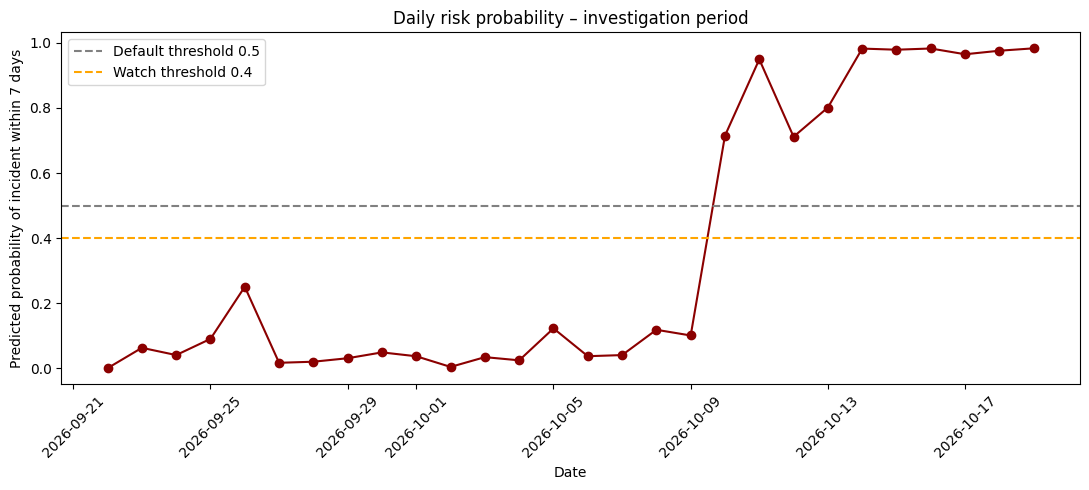

Earliest defensible escalation point:
2026-10-10   probability = 0.715


In [ ]:
# Risk probability over time + earliest escalation point


import matplotlib.pyplot as plt

risk_inv_sorted = risk_inv.sort_values("date")

plt.figure(figsize=(11, 5))
plt.plot(risk_inv_sorted["date"], risk_inv_sorted["risk_prob"], marker="o", color="darkred")
plt.axhline(0.5, color="gray", linestyle="--", label="Default threshold 0.5")
plt.axhline(0.4, color="orange", linestyle="--", label="Watch threshold 0.4")
plt.title("Daily risk probability – investigation period")
plt.xlabel("Date")
plt.ylabel("Predicted probability of incident within 7 days")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Earliest day that crosses 0.5
escalation = risk_inv_sorted[risk_inv_sorted["risk_prob"] >= 0.5]
if len(escalation) > 0:
    first = escalation.iloc[0]
    print("Earliest defensible escalation point:")
    print(first["date"].date(), "  probability =", round(first["risk_prob"], 3))
else:
    print("No day reached 0.5")

In [ ]:
#Pull key event IDs for the timeline

events = pd.read_csv("egs_security_event_logs.csv", parse_dates=["timestamp"])

# Focus on the high-risk window (approx 10–19 Oct)
window = events[
    (events["timestamp"] >= "2026-10-10") &
    (events["timestamp"] <= "2026-10-19 23:59:59")
]

# Show interesting / high-severity or OT-related events
interesting = window[
    (window["severity"].isin(["High", "Critical"])) |
    (window["event_type"].str.contains("MODBUS|LOGIN_FAIL|DNS|OT|WRITE", case=False, na=False)) |
    (window["action"] == "BLOCK")
]
print(interesting[["event_id", "timestamp", "source_type", "source_asset",
                   "event_type", "action", "severity", "indicator"]].head(30).to_string())

      event_id           timestamp source_type source_asset   event_type action severity                  indicator
1072  EVT01073 2026-10-10 00:39:35      OT_IDS       HMI-01  MODBUS_READ  ALLOW      Low                        NaN
1076  EVT01077 2026-10-10 04:11:39         DNS       DNS-01    DNS_QUERY  ALLOW      Low            erp.egs.example
1078  EVT01079 2026-10-10 04:45:03      OT_IDS       HMI-01  MODBUS_READ  ALLOW      Low                        NaN
1083  EVT01084 2026-10-10 06:48:14         DNS       DNS-01    DNS_QUERY  ALLOW      Low            erp.egs.example
1085  EVT01086 2026-10-10 07:18:58      OT_IDS       HMI-01  MODBUS_READ  ALLOW      Low                        NaN
1087  EVT01088 2026-10-10 07:47:17         DNS       DNS-01    DNS_QUERY  ALLOW      Low            weather.example
1089  EVT01090 2026-10-10 08:04:09      OT_IDS       HMI-01  MODBUS_READ  ALLOW      Low                        NaN
1093  EVT01094 2026-10-10 08:14:23         DNS       DNS-01    DNS_QUERY

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

SEED = 8213026
np.random.seed(SEED)

# ----- 1. Train the risk model again -----
risk_train = pd.read_csv("egs_daily_risk_training.csv")

feature_cols = [
    "failed_remote_logins", "new_external_ips", "suspicious_dns_queries",
    "critical_vulnerabilities", "mean_patch_age_days", "high_severity_edr_alerts",
    "ot_scan_attempts", "high_relevance_threat_reports", "vendor_access_sessions",
    "after_hours_admin_actions"
]

X = risk_train[feature_cols]
y = risk_train["incident_within_7d"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)

risk_clf = RandomForestClassifier(
    n_estimators=200, random_state=SEED, class_weight="balanced"
)
risk_clf.fit(X_tr_s, y_tr)

# ----- 2. Score the adversarial cases -----
adv_risk = pd.read_csv("egs_adversarial_risk_cases.csv")
X_adv = scaler.transform(adv_risk[feature_cols])
adv_risk["predicted_prob"] = risk_clf.predict_proba(X_adv)[:, 1]
adv_risk["predicted_label"] = risk_clf.predict(X_adv)

print("Adversarial risk scores:")
print(adv_risk[["case_id", "variant", "predicted_prob", "predicted_label"]].to_string())

Adversarial risk scores:
  case_id               variant  predicted_prob  predicted_label
0    AR01       baseline_attack           0.925                1
1    AR02          low_and_slow           0.675                1
2    AR03   distributed_sources           0.915                1
3    AR04   living_off_the_land           0.880                1
4    AR05  suppressed_telemetry           0.610                1
